In [48]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    accuracy_score, classification_report, confusion_matrix,
)
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')

# Đọc dữ liệu
df = pd.read_csv('smartphones_data.csv.csv')
print(f"Kích thước ban đầu: {df.shape[0]} dòng, {df.shape[1]} cột")
print("\nDanh sách các cột:")
print(df.columns.tolist())
print("\nThông tin kiểu dữ liệu:")
print(df.info())


Kích thước ban đầu: 3260 dòng, 20 cột

Danh sách các cột:
['brand_name', 'Name', 'Price', 'RAM', 'OS', 'storage', 'Battery_cap', 'has_fast_charging', 'has_fingerprints', 'has_nfc', 'has_5g', 'processor_brand', 'num_core', 'primery_rear_camera', 'Num_Rear_Cameras', 'primery_front_camera', 'num_front_camera', 'display_size(inch)', 'refresh_rate(hz)', 'display_types']

Thông tin kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3260 entries, 0 to 3259
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand_name            3260 non-null   object 
 1   Name                  3260 non-null   object 
 2   Price                 3260 non-null   int64  
 3   RAM                   3260 non-null   float64
 4   OS                    3260 non-null   object 
 5   storage               3260 non-null   float64
 6   Battery_cap           3260 non-null   int64  
 7   has_fast_charging     3260 non-null 

In [49]:
# Xóa dữ liệu trùng lặp
df = df.drop_duplicates()
print(f"\nKích thước sau khi xóa dữ liệu trùng lặp: {df.shape[0]} dòng, {df.shape[1]} cột")



Kích thước sau khi xóa dữ liệu trùng lặp: 3260 dòng, 20 cột


In [50]:
print("\nSố lượng missing values trước khi xử lý:")
print(df.isnull().sum())



Số lượng missing values trước khi xử lý:
brand_name                 0
Name                       0
Price                      0
RAM                        0
OS                         0
storage                    0
Battery_cap                0
has_fast_charging          0
has_fingerprints         726
has_nfc                  726
has_5g                   726
processor_brand            0
num_core                 175
primery_rear_camera        0
Num_Rear_Cameras           0
primery_front_camera       0
num_front_camera           0
display_size(inch)         0
refresh_rate(hz)        1731
display_types              0
dtype: int64


In [51]:
# Điền median cho cột số, mode cho cột phân loại
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Loại bỏ giá trị không hợp lệ
df = df[(df['RAM'] > 0) & (df['storage'] > 0) & (df['Battery_cap'] > 0)]
df = df[(df['Num_Rear_Cameras'] > 0) & (df['num_front_camera'] > 0)]
df = df[df['display_size(inch)'] <= 8]

# Mã hóa binary Yes/No → 1/0
binary_cols = ['has_fast_charging', 'has_fingerprints', 'has_nfc', 'has_5g']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

# Chuẩn hóa OS thành 3 nhóm: android, ios, other
df['OS'] = df['OS'].str.lower()
df['OS'] = df['OS'].apply(lambda x: x if pd.notna(x) and x in ['android', 'ios'] else 'other')


In [52]:
print("\nBẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN DẠNG SỐ")
numeric_cols_for_desc = df.select_dtypes(include=[np.number])
summary_stats = numeric_cols_for_desc.describe().round(2)
print(summary_stats)



BẢNG THỐNG KÊ MÔ TẢ CÁC BIẾN DẠNG SỐ
           Price      RAM  storage  Battery_cap  has_fast_charging  \
count    3259.00  3259.00  3259.00      3259.00            3259.00   
mean    20138.48     5.06   111.92      4163.01               0.47   
std     24024.50     3.25   126.72      1312.33               0.50   
min      2500.00     0.25     0.31      1100.00               0.00   
25%      7490.00     3.00    32.00      3005.00               0.00   
50%     11999.00     4.00    64.00      4500.00               0.00   
75%     21999.00     8.00   128.00      5000.00               1.00   
max    200999.00    24.00  1024.00     22000.00               1.00   

       has_fingerprints  has_nfc   has_5g  num_core  primery_rear_camera  \
count           3259.00  3259.00  3259.00   3259.00              3259.00   
mean               0.96     0.26     0.31      7.14                32.65   
std                0.20     0.44     0.46      1.65                29.40   
min                0.00    

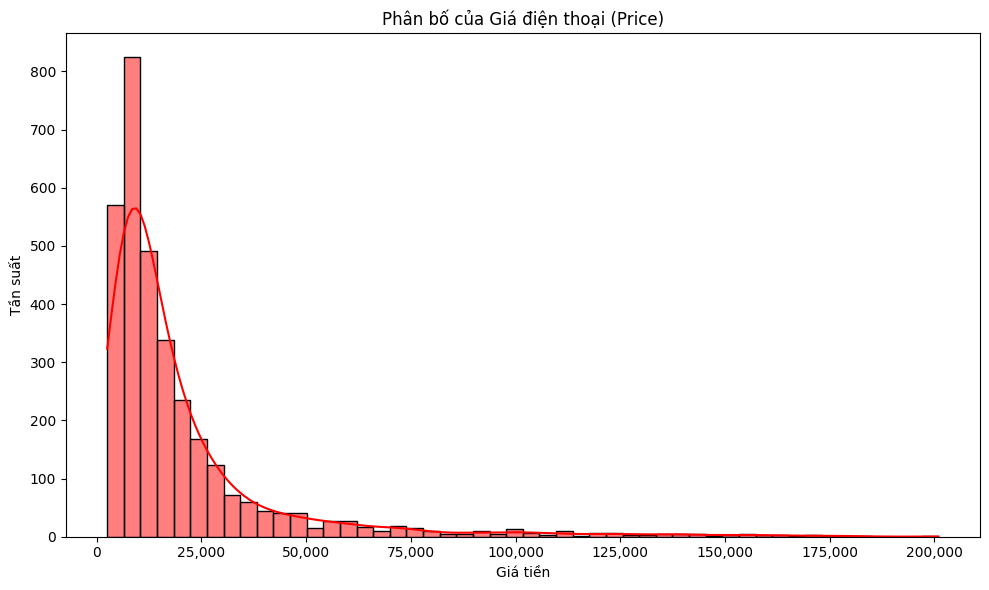

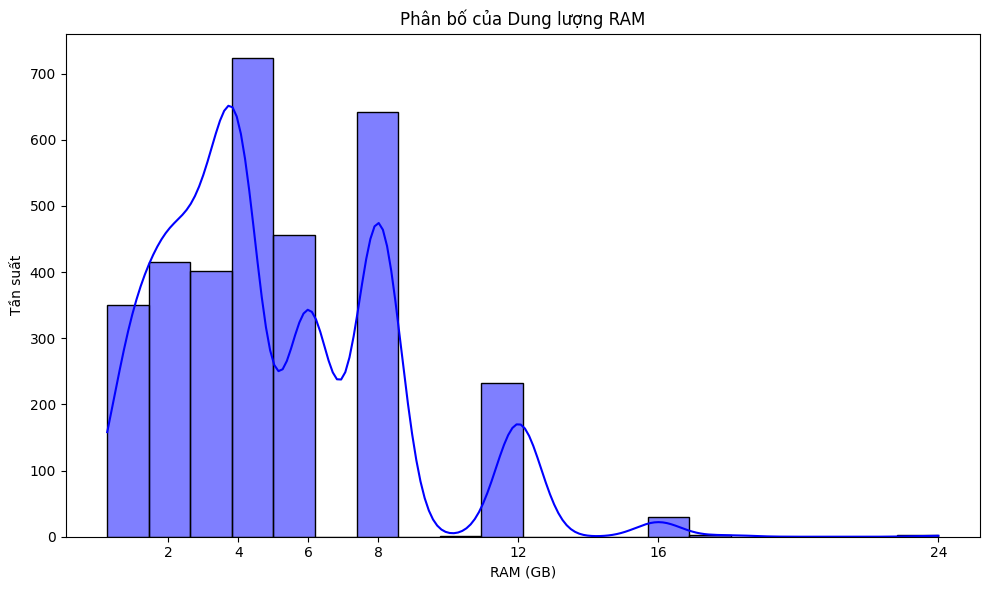

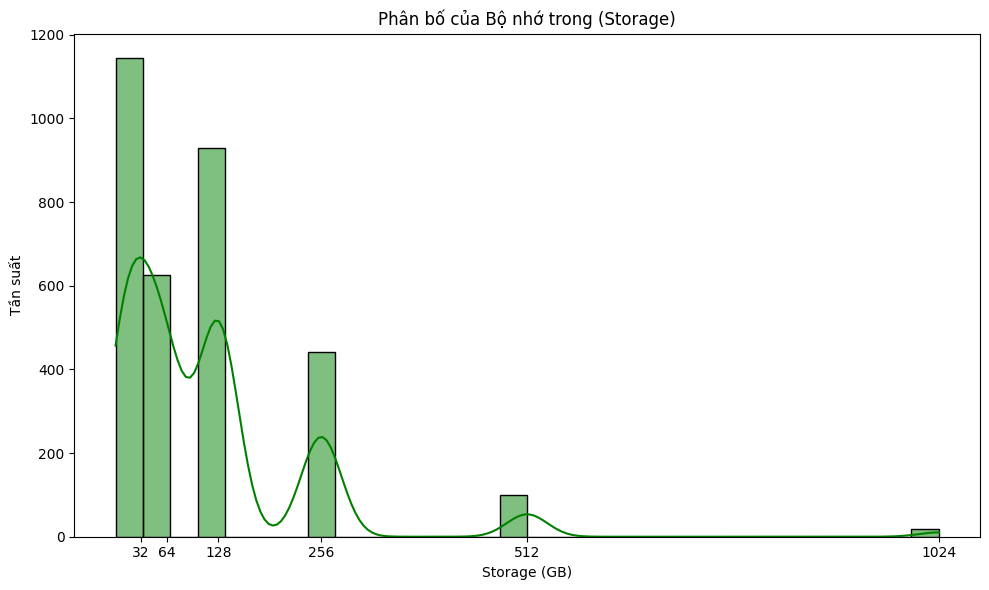

In [53]:
sns.set_theme(style="whitegrid")
plt.style.use('default')
comma_formatter = FuncFormatter(lambda x, pos: f"{int(x):,}")

# Phân bố giá điện thoại
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Price', kde=True, color='red', bins=50, edgecolor='black')
plt.gca().xaxis.set_major_formatter(comma_formatter)
plt.title('Phân bố của Giá điện thoại (Price)')
plt.xlabel('Giá tiền')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()

# Phân bố RAM
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='RAM', kde=True, color='blue', bins=20, edgecolor='black')
plt.xticks([2, 4, 6, 8, 12, 16, 24])
plt.title('Phân bố của Dung lượng RAM')
plt.xlabel('RAM (GB)')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()

# Phân bố bộ nhớ trong
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='storage', kde=True, color='green', bins=30, edgecolor='black')
plt.xticks([32, 64, 128, 256, 512, 1024])
plt.title('Phân bố của Bộ nhớ trong (Storage)')
plt.xlabel('Storage (GB)')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()


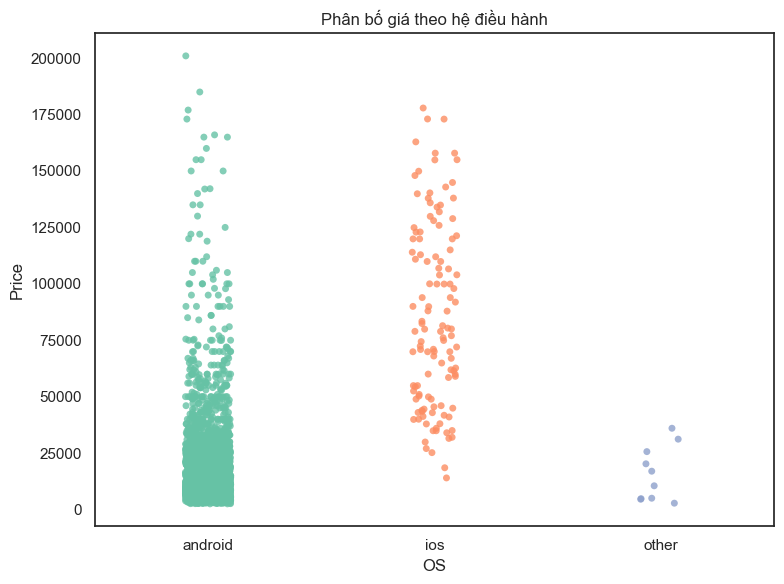

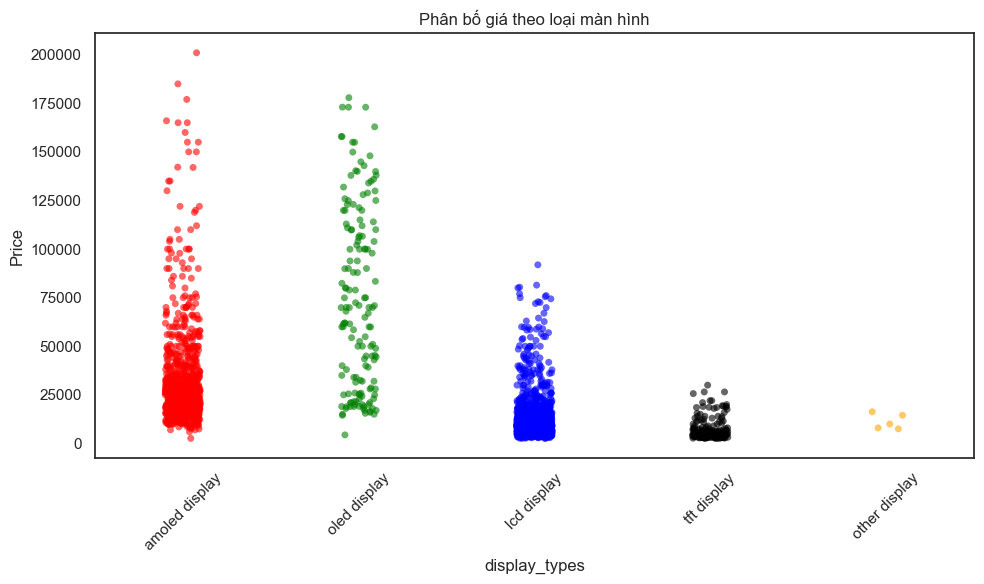

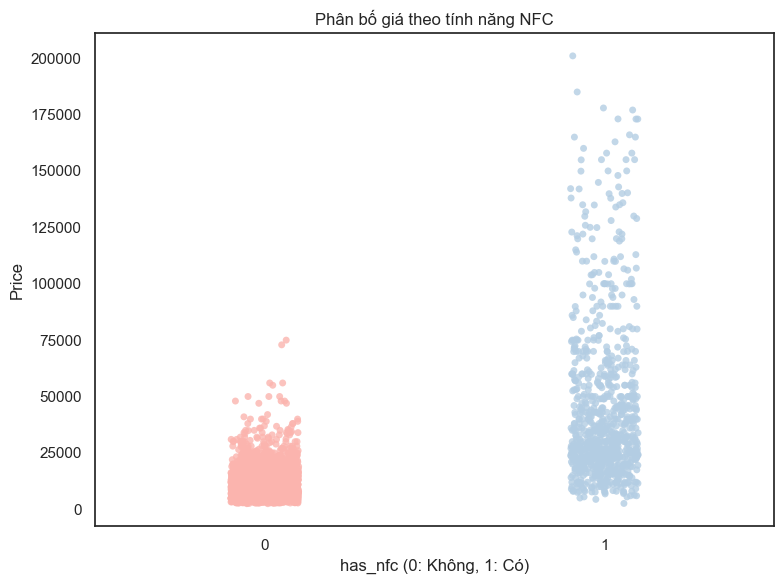

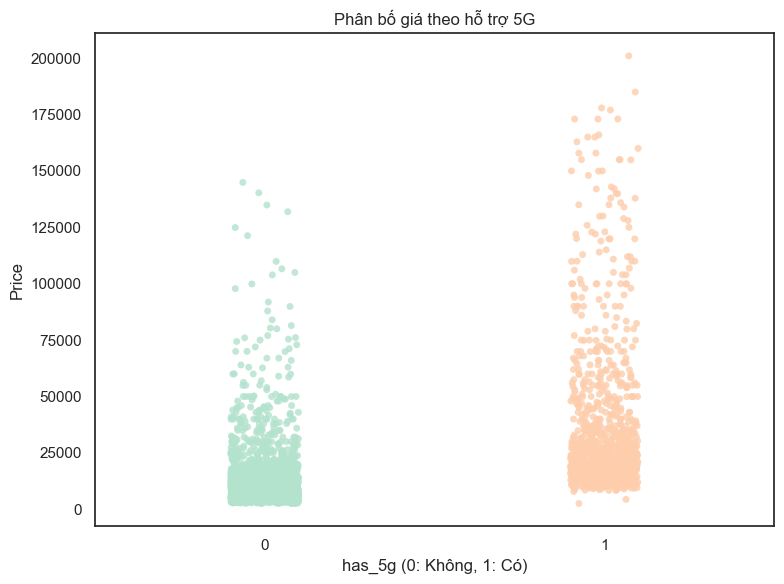

In [54]:
sns.set_theme(style="white")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# OS vs Price
plt.figure(figsize=(8, 6))
sns.stripplot(data=df, x='OS', y='Price', jitter=True, alpha=0.8, palette='Set2')
plt.title('Phân bố giá theo hệ điều hành')
plt.xlabel('OS')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# Loại màn hình vs Price
plt.figure(figsize=(10, 6))
palette_custom = {
    'amoled display': 'red',
    'oled display': 'green',
    'lcd display': 'blue',
    'tft display': 'black',
    'other display': 'orange'
}
sns.stripplot(data=df, x='display_types', y='Price', jitter=True, alpha=0.6, palette=palette_custom)
plt.title('Phân bố giá theo loại màn hình')
plt.xlabel('display_types')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# NFC vs Price
plt.figure(figsize=(8, 6))
sns.stripplot(data=df, x='has_nfc', y='Price', jitter=True, alpha=0.8, palette='Pastel1')
plt.title('Phân bố giá theo tính năng NFC')
plt.xlabel('has_nfc (0: Không, 1: Có)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# 5G vs Price
plt.figure(figsize=(8, 6))
sns.stripplot(data=df, x='has_5g', y='Price', jitter=True, alpha=0.8, palette='Pastel2')
plt.title('Phân bố giá theo hỗ trợ 5G')
plt.xlabel('has_5g (0: Không, 1: Có)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()


In [55]:
# Bỏ cột định danh, áp dụng One-Hot Encoding cho biến categorical
if 'Name' in df.columns:
    df = df.drop(columns=['Name'])

cols_to_encode = ['brand_name', 'processor_brand', 'display_types', 'OS']
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=False)

# Chuyển kiểu boolean từ get_dummies về int
for col in df.select_dtypes(include=['boolean']).columns:
    df[col] = df[col].astype(int)


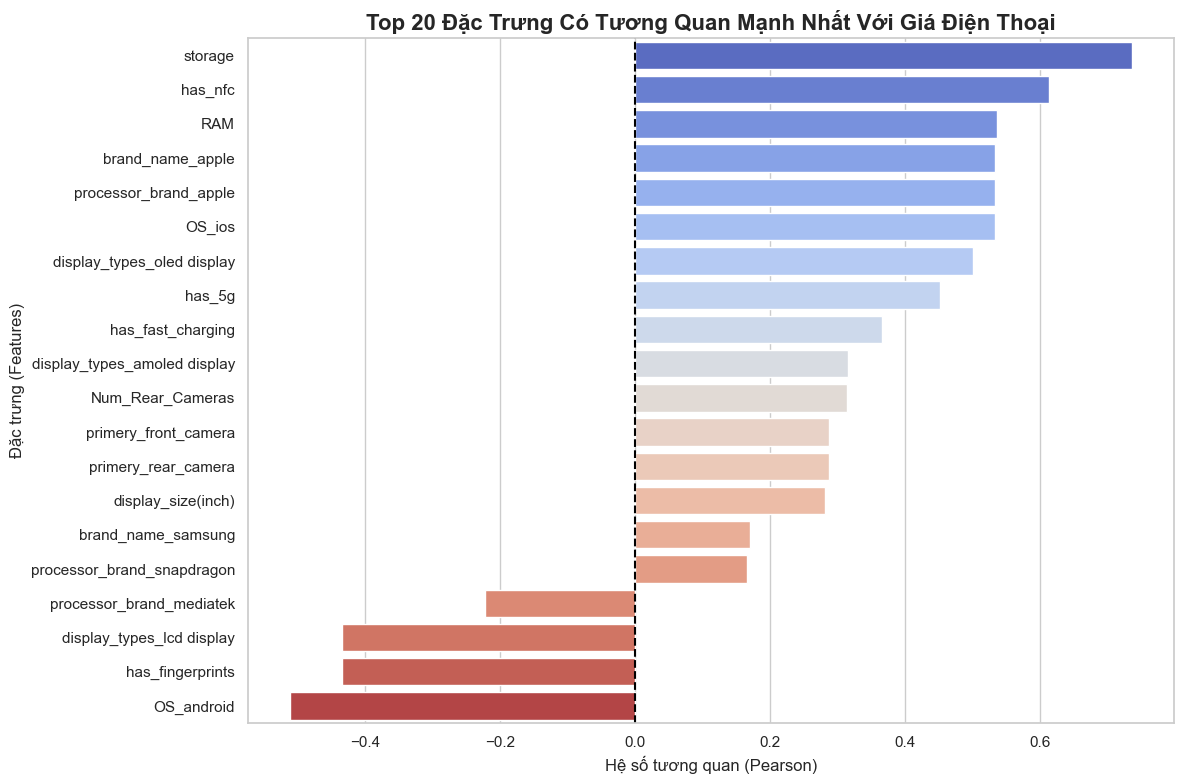

In [56]:
plt.style.use('default')
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_with_price = numeric_df.corr()['Price'].drop('Price')
top_features = corr_with_price.abs().nlargest(20).index
corr_filtered = corr_with_price[top_features].sort_values(ascending=False)
sns.barplot(x=corr_filtered.values, y=corr_filtered.index, palette='coolwarm')

plt.title('Top 20 Đặc Trưng Có Tương Quan Mạnh Nhất Với Giá Điện Thoại', fontsize=16, fontweight='bold')
plt.xlabel('Hệ số tương quan (Pearson)', fontsize=12)
plt.ylabel('Đặc trưng (Features)', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


In [57]:
scaler = StandardScaler()

# Chỉ chuẩn hóa các cột số đầu vào (không chuẩn hóa Price và cột binary)
numeric_features_to_scale = [
    'RAM', 'storage', 'Battery_cap', 'num_core',
    'primery_rear_camera', 'Num_Rear_Cameras',
    'primery_front_camera', 'num_front_camera',
    'display_size(inch)', 'refresh_rate(hz)'
]

df[numeric_features_to_scale] = scaler.fit_transform(df[numeric_features_to_scale])

print(f"\nKích thước dữ liệu sau khi xử lí: {df.shape[0]} dòng, {df.shape[1]} cột")
print(df.head())
print(df.describe())



Kích thước dữ liệu sau khi xử lí: 3259 dòng, 71 cột
    Price       RAM   storage  Battery_cap  has_fast_charging  \
0   34999  0.903491  0.126929     1.400004                  1   
1   21999  0.903491  0.126929     1.400004                  1   
2   27999  0.903491  0.126929     1.400004                  1   
3  129999  2.133784  1.137190     0.637884                  1   
4   22999  0.903491  0.126929     1.018944                  1   

   has_fingerprints  has_nfc  has_5g  num_core  primery_rear_camera  ...  \
0                 1        0       1  0.522724             0.590197  ...   
1                 1        0       1  0.522724             0.590197  ...   
2                 1        0       1  0.522724             0.590197  ...   
3                 1        1       1  0.522724             5.692910  ...   
4                 1        0       1  0.522724             0.590197  ...   

   processor_brand_tru-mediatek  processor_brand_unisoc  \
0                             0         

Kích thước dữ liệu gốc: (3259, 70)


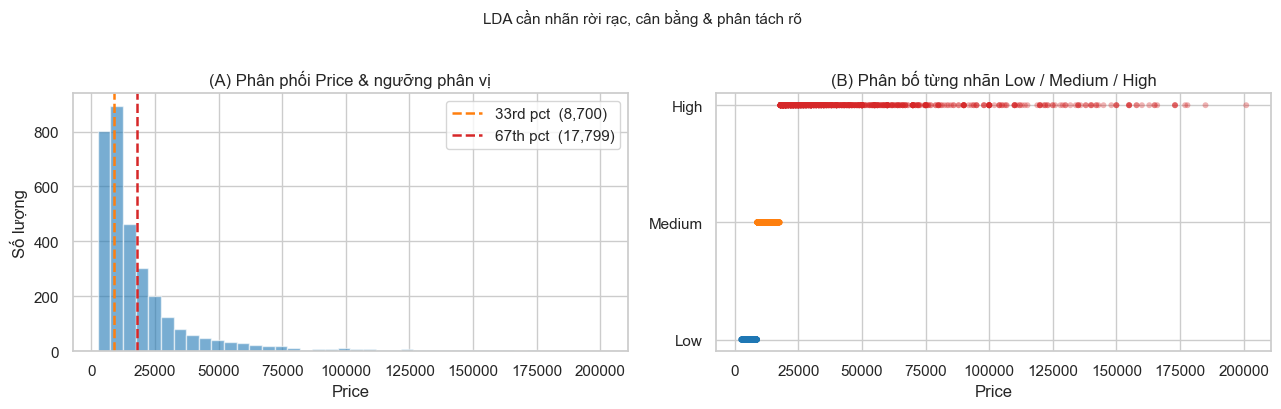

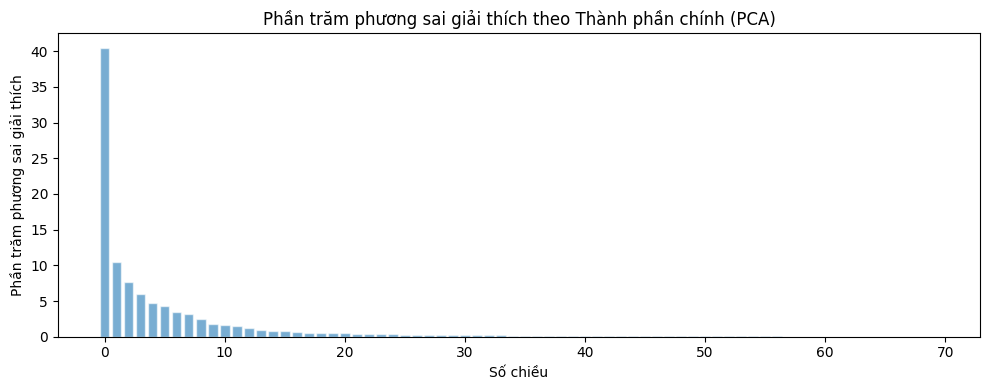

In [58]:
X = df.drop(columns=['Price'])
y = df['Price']
y_class = pd.qcut(df['Price'], q=3, labels=['Low', 'Medium', 'High'])
print(f"Kích thước dữ liệu gốc: {X.shape}")

# ── Biểu đồ minh hoạ lý do chia 3 phân vị ──────────────────────────────────
quantiles = df['Price'].quantile([1/3, 2/3])
q1, q2 = quantiles[1/3], quantiles[2/3]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (A) Histogram + đường phân vị
axes[0].hist(df['Price'], bins=40, color='tab:blue', alpha=0.6, edgecolor='white')
axes[0].axvline(q1, color='tab:orange', linewidth=1.8, linestyle='--',
                label=f'33rd pct  ({q1:,.0f})')
axes[0].axvline(q2, color='tab:red',    linewidth=1.8, linestyle='--',
                label=f'67th pct  ({q2:,.0f})')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Số lượng')
axes[0].set_title('(A) Phân phối Price & ngưỡng phân vị')
axes[0].legend()

# (B) Strip-plot màu theo nhãn
colors = {'Low': 'tab:blue', 'Medium': 'tab:orange', 'High': 'tab:red'}
for label, grp in df.assign(Class=y_class).groupby('Class', observed=True):
    axes[1].scatter(grp['Price'],
                    [label] * len(grp),
                    c=colors[label], alpha=0.35, s=18, edgecolors='none')
axes[1].set_xlabel('Price')
axes[1].set_title('(B) Phân bố từng nhãn Low / Medium / High')

plt.suptitle('LDA cần nhãn rời rạc, cân bằng & phân tách rõ',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()
# ────────────────────────────────────────────────────────────────────────────

# Giảm chiều bằng LDA (2 chiều)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y_class)

# Giảm chiều bằng PCA (toàn bộ chiều)
pca = PCA()
X_pca = pca.fit_transform(X)

plt.style.use('default')
explained_variance_pct = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(10, 4))
plt.bar(range(len(explained_variance_pct)), explained_variance_pct,
        alpha=0.6, color='tab:blue', edgecolor='white')
plt.xlabel('Số chiều')
plt.ylabel('Phần trăm phương sai giải thích')
plt.title('Phần trăm phương sai giải thích theo Thành phần chính (PCA)')
plt.tight_layout()
plt.show()


In [59]:
retained_variance_4pcs = np.sum(pca.explained_variance_ratio_[:4]) * 100
loss_variance_4pcs = 100 - retained_variance_4pcs

print(f"Thông tin giữ lại (4 PC đầu): {retained_variance_4pcs:.2f}%")
print(f"Phần trăm thông tin mất mát (khi dùng 4 PC đầu): {loss_variance_4pcs:.2f}%")

# Xác định biến gốc ảnh hưởng nhất đến PC1–PC4
feature_names = X.columns
n_pcs = 4
top_n_features = 3

print("\nCÁC BIẾN GỐC ẢNH HƯỞNG NHẤT ĐẾN 4 THÀNH PHẦN CHÍNH (PC1 - PC4):")
for i in range(n_pcs):
    importance = np.abs(pca.components_[i])
    top_indices = np.argsort(importance)[::-1][:top_n_features]
    print(f"\n[PC{i+1}] (giải thích {pca.explained_variance_ratio_[i]*100:.2f}% phương sai):")
    for rank, idx in enumerate(top_indices):
        feature = feature_names[idx]
        weight = pca.components_[i][idx]
        print(f"   {rank+1}. {feature:<20} | Trọng số: {weight:.4f}")


Thông tin giữ lại (4 PC đầu): 64.69%
Phần trăm thông tin mất mát (khi dùng 4 PC đầu): 35.31%

CÁC BIẾN GỐC ẢNH HƯỞNG NHẤT ĐẾN 4 THÀNH PHẦN CHÍNH (PC1 - PC4):

[PC1] (giải thích 40.46% phương sai):
   1. RAM                  | Trọng số: 0.3868
   2. display_size(inch)   | Trọng số: 0.3661
   3. Num_Rear_Cameras     | Trọng số: 0.3477

[PC2] (giải thích 10.53% phương sai):
   1. refresh_rate(hz)     | Trọng số: 0.6274
   2. Battery_cap          | Trọng số: -0.3245
   3. storage              | Trọng số: 0.3082

[PC3] (giải thích 7.67% phương sai):
   1. num_front_camera     | Trọng số: 0.9333
   2. refresh_rate(hz)     | Trọng số: -0.2373
   3. num_core             | Trọng số: 0.1325

[PC4] (giải thích 6.02% phương sai):
   1. refresh_rate(hz)     | Trọng số: 0.6148
   2. num_core             | Trọng số: 0.5400
   3. storage              | Trọng số: -0.3536


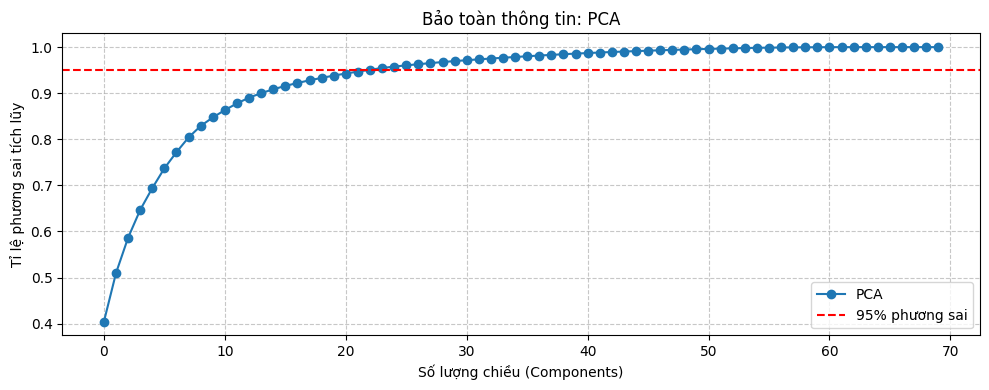

Số chiều cần để đạt >= 95% phương sai: 23


In [60]:
plt.figure(figsize=(10, 4))

pca_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot(pca_variance, marker='o', label='PCA')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% phương sai')
plt.xlabel('Số lượng chiều (Components)')
plt.ylabel('Tỉ lệ phương sai tích lũy')
plt.title('Bảo toàn thông tin: PCA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Số chiều cần để đạt >= 95% phương sai: {n_components_95}")


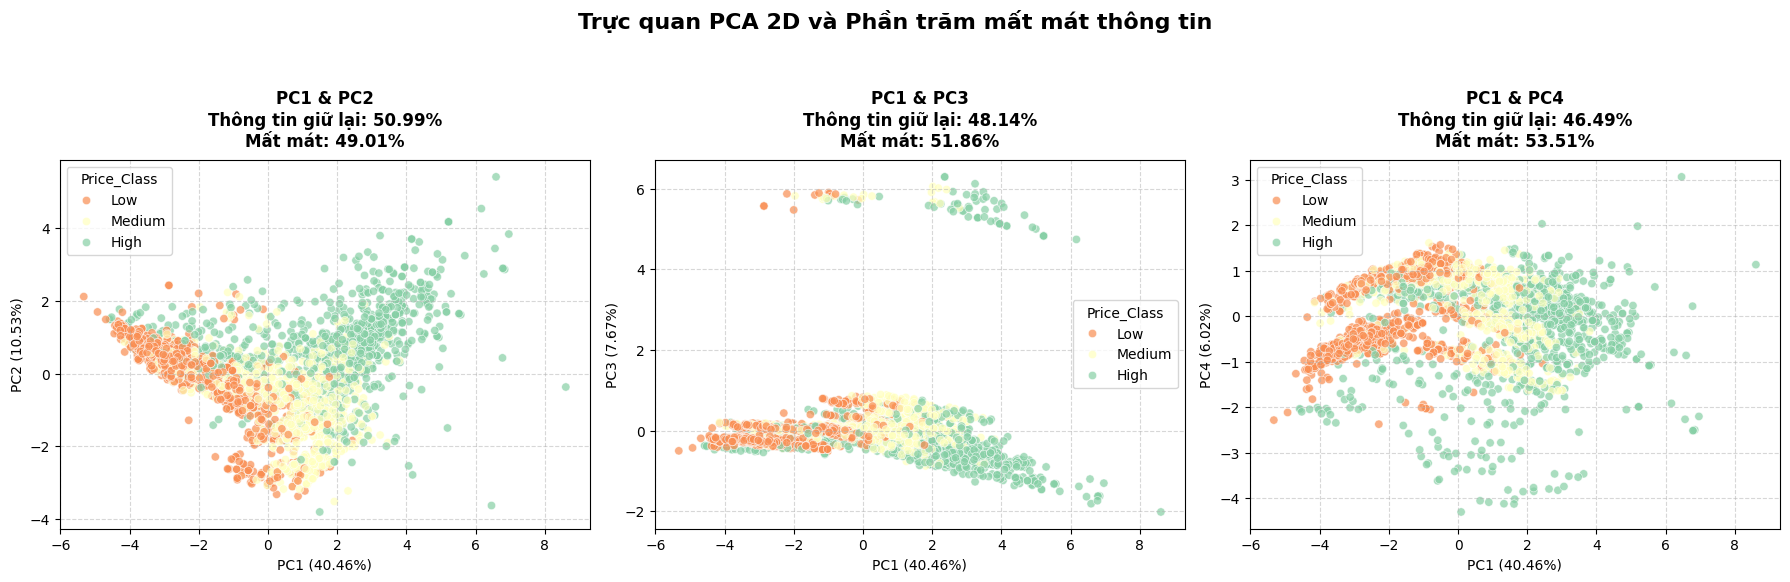

In [61]:
df_pca = pd.DataFrame(X_pca[:, :4], columns=['PC1', 'PC2', 'PC3', 'PC4'])
df_pca['Price_Class'] = y_class.values

var_ratios = pca.explained_variance_ratio_ * 100

pairs = [
    ('PC1', 'PC2', 0, 1),
    ('PC1', 'PC3', 0, 2),
    ('PC1', 'PC4', 0, 3)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for i, (col_x, col_y, idx_x, idx_y) in enumerate(pairs):
    retained_info = var_ratios[idx_x] + var_ratios[idx_y]
    loss_info = 100 - retained_info

    sns.scatterplot(data=df_pca, x=col_x, y=col_y, hue='Price_Class',
                    palette='Spectral', alpha=0.7, ax=axes[i])

    title = f"{col_x} & {col_y}\nThông tin giữ lại: {retained_info:.2f}%\nMất mát: {loss_info:.2f}%"
    axes[i].set_title(title, fontsize=12, fontweight='bold', pad=10)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].set_xlabel(f"{col_x} ({var_ratios[idx_x]:.2f}%)")
    axes[i].set_ylabel(f"{col_y} ({var_ratios[idx_y]:.2f}%)")

plt.suptitle('Trực quan PCA 2D và Phần trăm mất mát thông tin', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


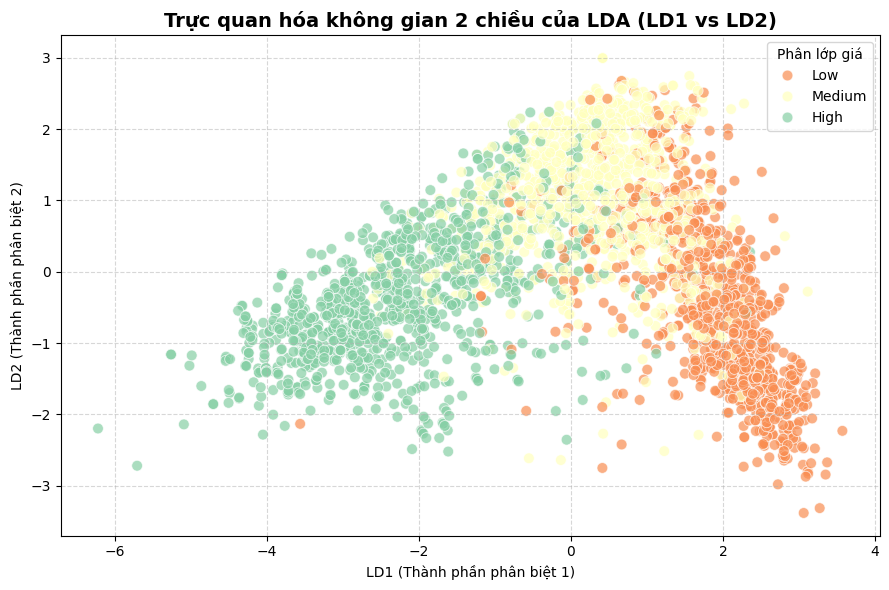

In [62]:
plt.figure(figsize=(9, 6))

df_lda_2d = pd.DataFrame({
    'LD1': X_lda[:, 0],
    'LD2': X_lda[:, 1],
    'Price_Class': y_class
})

sns.scatterplot(data=df_lda_2d, x='LD1', y='LD2', hue='Price_Class',
                palette='Spectral', alpha=0.7, s=60, edgecolor='w')

plt.title('Trực quan hóa không gian 2 chiều của LDA (LD1 vs LD2)', fontsize=14, fontweight='bold')
plt.xlabel('LD1 (Thành phần phân biệt 1)')
plt.ylabel('LD2 (Thành phần phân biệt 2)')
plt.legend(title='Phân lớp giá')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


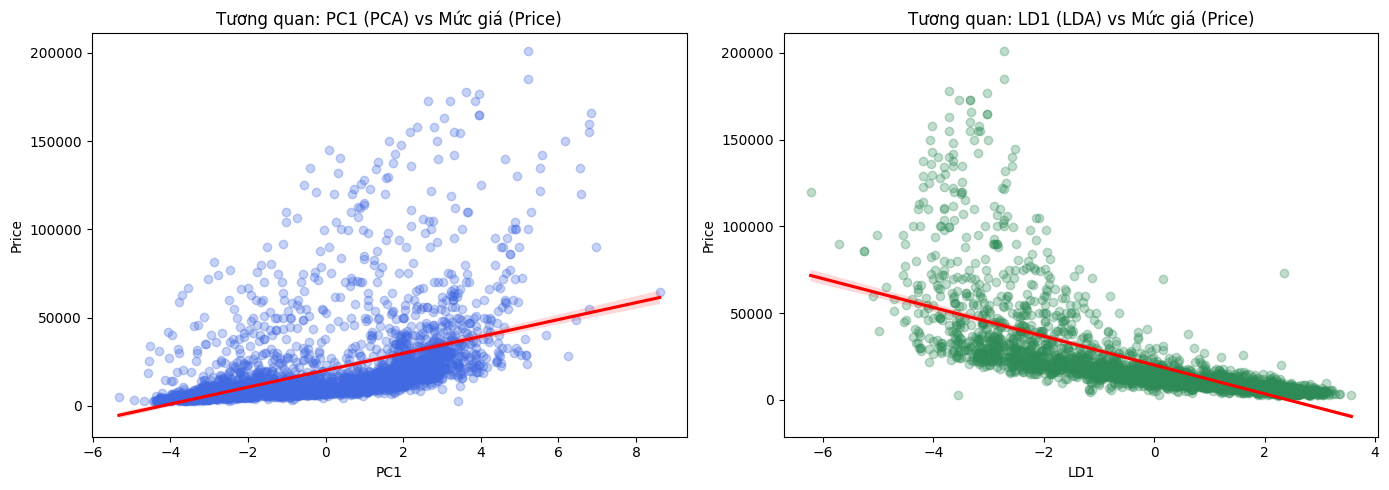

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1 (PCA) vs Price
sns.regplot(x=X_pca[:, 0], y=y, ax=axes[0],
            scatter_kws={'alpha': 0.3, 'color': 'royalblue'},
            line_kws={'color': 'red'})
axes[0].set_title('Tương quan: PC1 (PCA) vs Mức giá (Price)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('Price')

# LD1 (LDA) vs Price
sns.regplot(x=X_lda[:, 0], y=y, ax=axes[1],
            scatter_kws={'alpha': 0.3, 'color': 'seagreen'},
            line_kws={'color': 'red'})
axes[1].set_title('Tương quan: LD1 (LDA) vs Mức giá (Price)')
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()


### 1.3. Phân tích hồi quy



K tốt nhất (theo 5-Fold CV): k = 5  |  R² trung bình = 0.8700


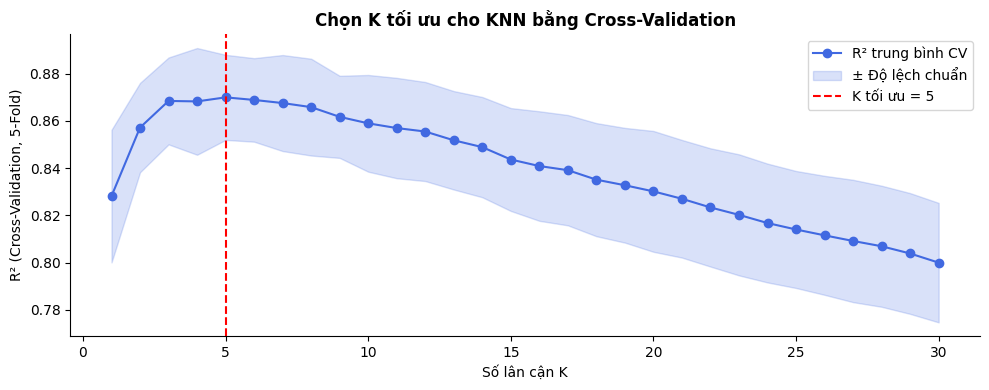


Số chiều PCA (1/3 gốc): 23

--- ĐÁNH GIÁ MÔ HÌNH HỒI QUY ---
Model                | Tỉ lệ | MAE Gốc (Train/Test)   | MSE Gốc (Train/Test)   | R2 Gốc (Train/Test)  | MAE PCA (Train/Test)   | MSE PCA (Train/Test)   | R2 PCA (Train/Test) 
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  [PCA tỷ lệ 8:2] Phương sai giữ lại: 95.10%
Linear Regression    | 8:2   | 6785 / 7229      | 113931196 / 133611575      | 0.804 / 0.760      | 6952 / 7523      | 126643169 / 150617992      | 0.782 / 0.730
                     | 7:3   | 6903 / 7098      | 116515143 / 123622642      | 0.809 / 0.751      | 7089 / 7286      | 130514146 / 135039272      | 0.787 / 0.728
                     | 6:4   | 7086 / 7142      | 120495895 / 118730860      | 0.807 / 0.766      | 7371 / 7264      | 136708780 / 125955932      | 0.781 / 0.751
---------------------------------------------------------

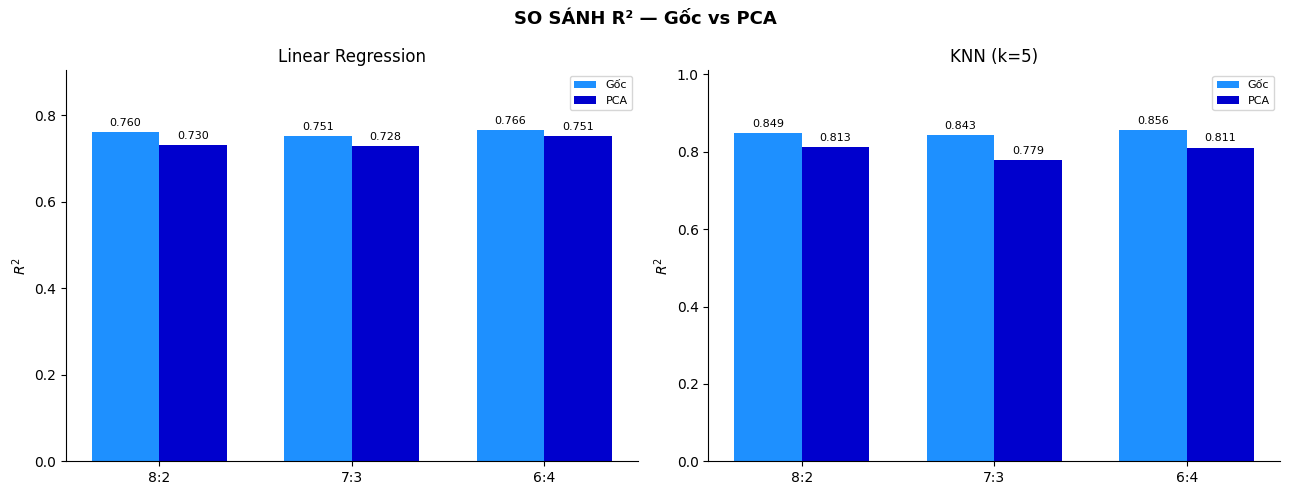

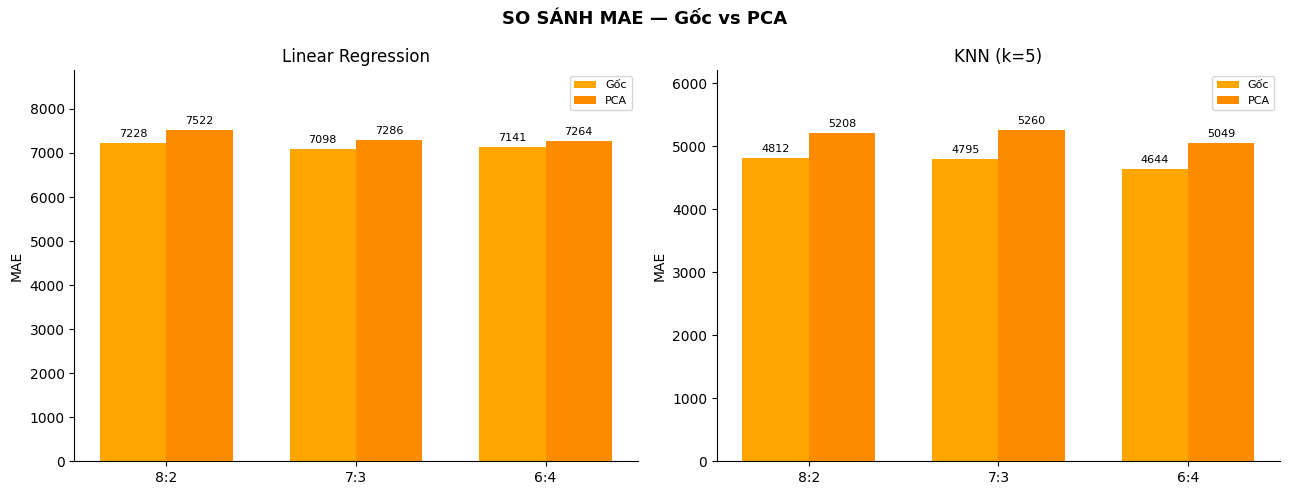

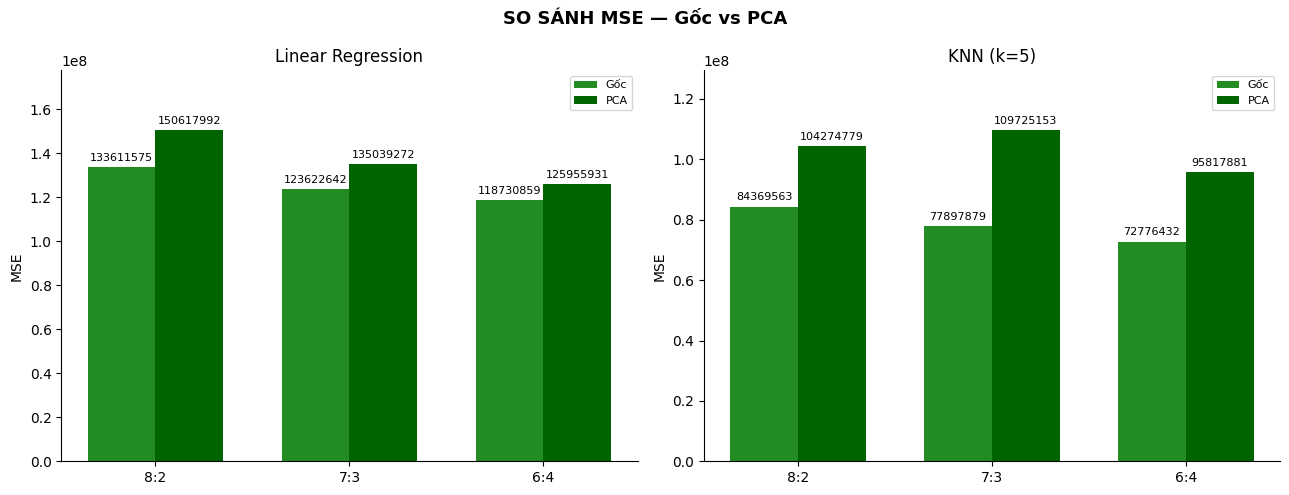

In [64]:
# Tìm k tối ưu cho KNN bằng 5-Fold Cross-Validation
k_range = range(1, 31)
cv_scores_mean = []
cv_scores_std  = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for k in k_range:
    knn_cv = KNeighborsRegressor(n_neighbors=k, metric='manhattan')
    scores = cross_val_score(knn_cv, X, y, cv=kf, scoring='r2')
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())
best_k = k_range[np.argmax(cv_scores_mean)]
best_r2 = max(cv_scores_mean)
print(f"K tốt nhất (theo 5-Fold CV): k = {best_k}  |  R² trung bình = {best_r2:.4f}")

fig_cv, ax_cv = plt.subplots(figsize=(10, 4))
ax_cv.plot(k_range, cv_scores_mean, marker='o', color='royalblue', label='R² trung bình CV')
ax_cv.fill_between(
    k_range,
    np.array(cv_scores_mean) - np.array(cv_scores_std),
    np.array(cv_scores_mean) + np.array(cv_scores_std),
    alpha=0.2, color='royalblue', label='± Độ lệch chuẩn'
)
ax_cv.axvline(x=best_k, color='red', linestyle='--', label=f'K tối ưu = {best_k}')
ax_cv.set_xlabel('Số lân cận K')
ax_cv.set_ylabel('R² (Cross-Validation, 5-Fold)')
ax_cv.set_title('Chọn K tối ưu cho KNN bằng Cross-Validation', fontweight='bold')
ax_cv.legend()
ax_cv.spines['top'].set_visible(False)
ax_cv.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Số chiều PCA = 1/3 số đặc trưng gốc
n_reduced = int(X.shape[1] / 3)
print(f"\nSố chiều PCA (1/3 gốc): {n_reduced}")

# Huấn luyện và đánh giá trên 3 tỷ lệ chia (8:2, 7:3, 6:4)
splits = [0.2, 0.3, 0.4]
models = {
    "Linear Regression": LinearRegression(),
    f"KNN (k={best_k})": KNeighborsRegressor(n_neighbors=best_k, metric='manhattan')
}

saved_results = {}

lr_r2_goc,  lr_r2_pca  = [], []
lr_mae_goc, lr_mae_pca = [], []
lr_mse_goc, lr_mse_pca = [], []

knn_r2_goc,  knn_r2_pca  = [], []
knn_mae_goc, knn_mae_pca = [], []
knn_mse_goc, knn_mse_pca = [], []

print("\n--- ĐÁNH GIÁ MÔ HÌNH HỒI QUY ---")
header = (
    f"{'Model':<20} | {'Tỉ lệ':<5} | "
    f"{'MAE Gốc (Train/Test)':<22} | {'MSE Gốc (Train/Test)':<22} | {'R2 Gốc (Train/Test)':<20} | "
    f"{'MAE PCA (Train/Test)':<22} | {'MSE PCA (Train/Test)':<22} | {'R2 PCA (Train/Test)':<20}"
)
print(header)
print("-" * len(header))

for name, model in models.items():
    first_row = True

    for split in splits:
        ratio_str = f"{int((1 - split) * 10)}:{int(split * 10)}"

        X_train_ori, X_test_ori, y_train, y_test = train_test_split(
            X, y, test_size=split, random_state=42
        )

        # PCA fit chỉ trên tập train để tránh data leakage
        pca_split = PCA(n_components=n_reduced, random_state=42)
        X_train_red = pca_split.fit_transform(X_train_ori)
        X_test_red  = pca_split.transform(X_test_ori)

        var_retained = pca_split.explained_variance_ratio_.sum() * 100
        if first_row:
            print(f"  [PCA tỷ lệ {ratio_str}] Phương sai giữ lại: {var_retained:.2f}%")

        # Đánh giá trên dữ liệu gốc
        model.fit(X_train_ori, y_train)
        pred_ori_train = model.predict(X_train_ori)
        pred_ori_test  = model.predict(X_test_ori)

        mae_ori_train = mean_absolute_error(y_train, pred_ori_train)
        mae_ori_test  = mean_absolute_error(y_test,  pred_ori_test)
        mse_ori_train = mean_squared_error(y_train,  pred_ori_train)
        mse_ori_test  = mean_squared_error(y_test,   pred_ori_test)
        r2_ori_train  = r2_score(y_train, pred_ori_train)
        r2_ori_test   = r2_score(y_test,  pred_ori_test)

        # Đánh giá trên dữ liệu PCA
        model.fit(X_train_red, y_train)
        pred_red_train = model.predict(X_train_red)
        pred_red_test  = model.predict(X_test_red)

        mae_red_train = mean_absolute_error(y_train, pred_red_train)
        mae_red_test  = mean_absolute_error(y_test,  pred_red_test)
        mse_red_train = mean_squared_error(y_train,  pred_red_train)
        mse_red_test  = mean_squared_error(y_test,   pred_red_test)
        r2_red_train  = r2_score(y_train, pred_red_train)
        r2_red_test   = r2_score(y_test,  pred_red_test)

        # Lưu kết quả tỷ lệ 6:4 để vẽ biểu đồ phần dư
        if split == 0.4:
            model.fit(X_train_ori, y_train)
            saved_results[name] = {
                "y_test": y_test,
                "y_pred": model.predict(X_test_ori)
            }

        if "Linear" in name:
            lr_r2_goc.append(r2_ori_test);   lr_r2_pca.append(r2_red_test)
            lr_mae_goc.append(mae_ori_test);  lr_mae_pca.append(mae_red_test)
            lr_mse_goc.append(mse_ori_test);  lr_mse_pca.append(mse_red_test)
        else:
            knn_r2_goc.append(r2_ori_test);   knn_r2_pca.append(r2_red_test)
            knn_mae_goc.append(mae_ori_test);  knn_mae_pca.append(mae_red_test)
            knn_mse_goc.append(mse_ori_test);  knn_mse_pca.append(mse_red_test)

        display_name = name if first_row else ""
        print(
            f"{display_name:<20} | {ratio_str:<5} | "
            f"{mae_ori_train:.0f} / {mae_ori_test:.0f}{'':>5} | "
            f"{mse_ori_train:.0f} / {mse_ori_test:.0f}{'':>5} | "
            f"{r2_ori_train:.3f} / {r2_ori_test:.3f}{'':>5} | "
            f"{mae_red_train:.0f} / {mae_red_test:.0f}{'':>5} | "
            f"{mse_red_train:.0f} / {mse_red_test:.0f}{'':>5} | "
            f"{r2_red_train:.3f} / {r2_red_test:.3f}"
        )
        first_row = False

    print("-" * len(header))

# Biểu đồ so sánh R², MAE, MSE: Gốc vs PCA cho LR và KNN
labels = ['8:2', '7:3', '6:4']
x = np.arange(len(labels))
w = 0.35

def style_ax(ax, ylabel, ylim_data, title):
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, max(ylim_data) * 1.18)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def add_bar_labels(ax, rects_list, fmt):
    for rects in rects_list:
        ax.bar_label(rects, padding=3, fmt=fmt, fontsize=8)

metrics = [
    ("R²",  "$R^2$", "%.3f", lr_r2_goc,  lr_r2_pca,  knn_r2_goc,  knn_r2_pca,  "dodgerblue",  "mediumblue"),
    ("MAE", "MAE",   "%d",   lr_mae_goc, lr_mae_pca, knn_mae_goc, knn_mae_pca, "orange",       "darkorange"),
    ("MSE", "MSE",   "%d",   lr_mse_goc, lr_mse_pca, knn_mse_goc, knn_mse_pca, "forestgreen",  "darkgreen"),
]

knn_label = f"KNN (k={best_k})"

for metric_name, ylabel, fmt, lr_g, lr_p, knn_g, knn_p, c1, c2 in metrics:
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'SO SÁNH {metric_name} — Gốc vs PCA', fontsize=13, fontweight='bold')

    r1 = axL.bar(x - w/2, lr_g,  w, label='Gốc', color=c1)
    r2 = axL.bar(x + w/2, lr_p,  w, label='PCA', color=c2)
    style_ax(axL, ylabel, lr_g + lr_p, 'Linear Regression')
    add_bar_labels(axL, [r1, r2], fmt)

    r3 = axR.bar(x - w/2, knn_g, w, label='Gốc', color=c1)
    r4 = axR.bar(x + w/2, knn_p, w, label='PCA', color=c2)
    style_ax(axR, ylabel, knn_g + knn_p, knn_label)
    add_bar_labels(axR, [r3, r4], fmt)

    plt.tight_layout()
    plt.show()


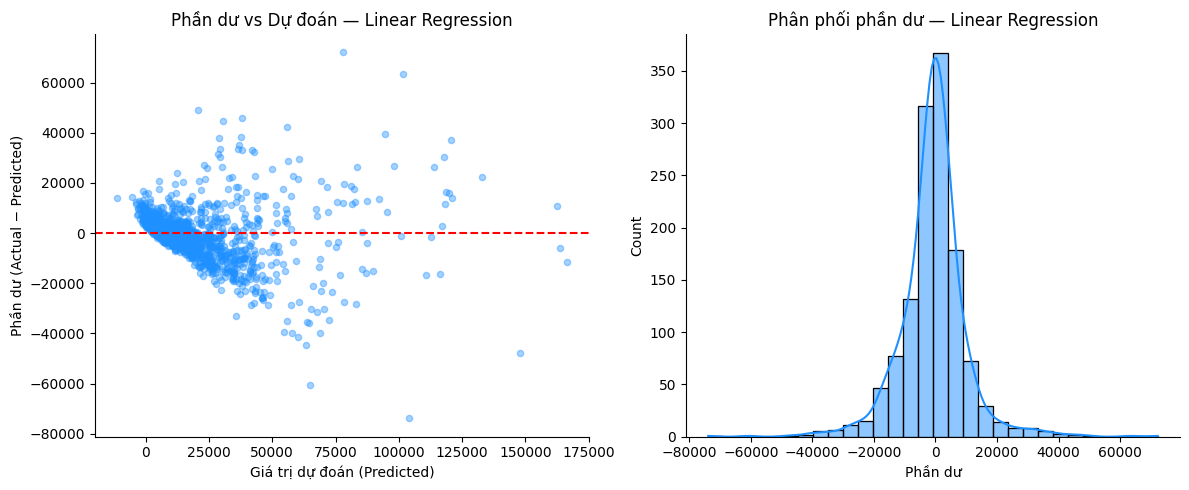

In [65]:
# Đánh giá phần dư — Linear Regression (tỷ lệ 6:4)
y_test_lr = saved_results["Linear Regression"]["y_test"]
y_pred_lr = saved_results["Linear Regression"]["y_pred"]

residuals = y_test_lr - y_pred_lr

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(y_pred_lr, residuals, alpha=0.4, color='dodgerblue', s=20)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel('Giá trị dự đoán (Predicted)')
ax1.set_ylabel('Phần dư (Actual − Predicted)')
ax1.set_title('Phần dư vs Dự đoán — Linear Regression')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

sns.histplot(residuals, kde=True, bins=30, ax=ax2, color='dodgerblue')
ax2.set_title('Phân phối phần dư — Linear Regression')
ax2.set_xlabel('Phần dư')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


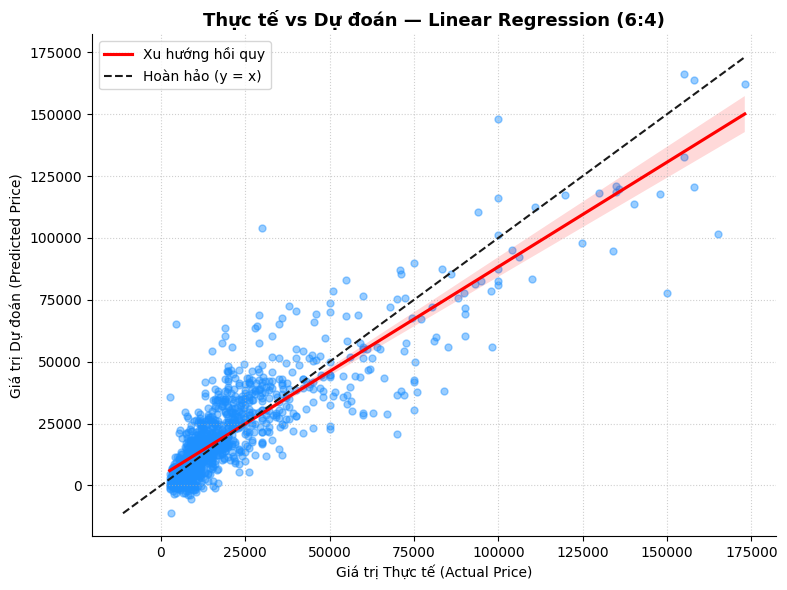

In [66]:
# Thực tế vs Dự đoán — Linear Regression (tỷ lệ 6:4)
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    x=y_test_lr, y=y_pred_lr, ax=ax,
    scatter_kws={'alpha': 0.45, 'color': 'dodgerblue', 's': 25},
    line_kws={'color': 'red', 'label': 'Xu hướng hồi quy'}
)

lo, hi = min(y_test_lr.min(), y_pred_lr.min()), max(y_test_lr.max(), y_pred_lr.max())
ax.plot([lo, hi], [lo, hi], 'k--', label='Hoàn hảo (y = x)')

ax.set_xlabel('Giá trị Thực tế (Actual Price)')
ax.set_ylabel('Giá trị Dự đoán (Predicted Price)')
ax.set_title('Thực tế vs Dự đoán — Linear Regression (6:4)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


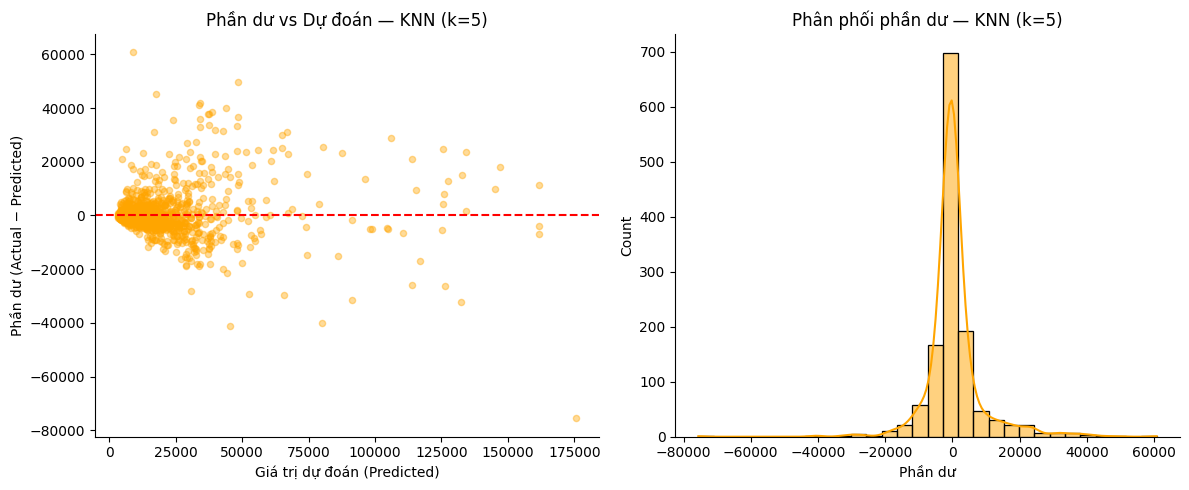

In [67]:
# Đánh giá phần dư — KNN tối ưu (tỷ lệ 6:4)
knn_key = [k for k in saved_results if 'KNN' in k][0]
y_test_knn = saved_results[knn_key]["y_test"]
y_pred_knn = saved_results[knn_key]["y_pred"]

residuals_knn = y_test_knn - y_pred_knn

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(y_pred_knn, residuals_knn, alpha=0.4, color='orange', s=20)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel('Giá trị dự đoán (Predicted)')
ax1.set_ylabel('Phần dư (Actual − Predicted)')
ax1.set_title(f'Phần dư vs Dự đoán — {knn_key}')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

sns.histplot(residuals_knn, kde=True, bins=30, ax=ax2, color='orange')
ax2.set_title(f'Phân phối phần dư — {knn_key}')
ax2.set_xlabel('Phần dư')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


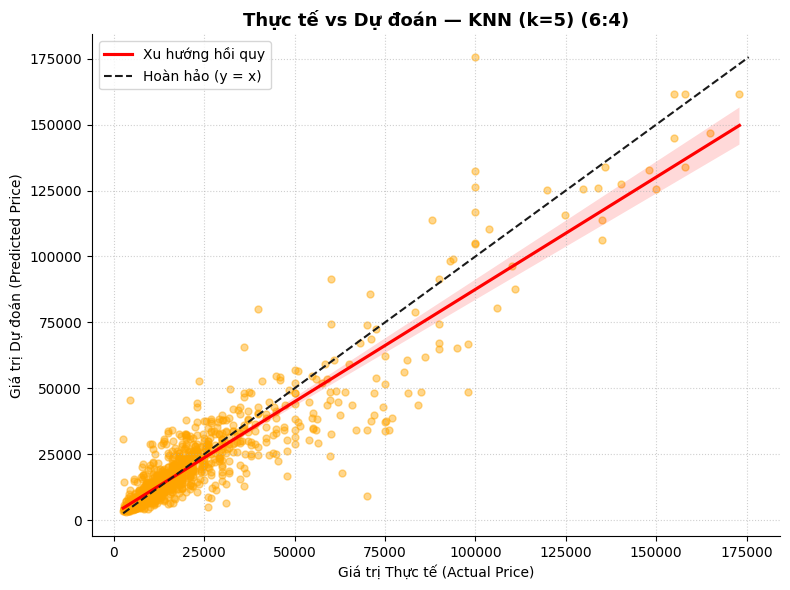

In [68]:
# Thực tế vs Dự đoán — KNN tối ưu (tỷ lệ 6:4)
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    x=y_test_knn, y=y_pred_knn, ax=ax,
    scatter_kws={'alpha': 0.45, 'color': 'orange', 's': 25},
    line_kws={'color': 'red', 'label': 'Xu hướng hồi quy'}
)

lo, hi = min(y_test_knn.min(), y_pred_knn.min()), max(y_test_knn.max(), y_pred_knn.max())
ax.plot([lo, hi], [lo, hi], 'k--', label='Hoàn hảo (y = x)')

ax.set_xlabel('Giá trị Thực tế (Actual Price)')
ax.set_ylabel('Giá trị Dự đoán (Predicted Price)')
ax.set_title(f'Thực tế vs Dự đoán — {knn_key} (6:4)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


1.4 Phân cụm hồi quy

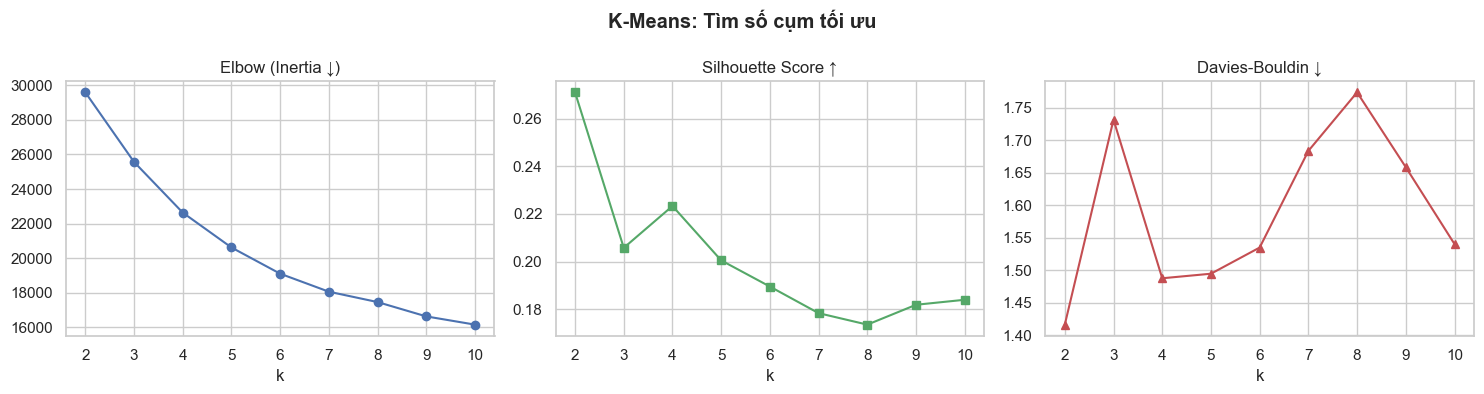

k tối ưu = 2
Silhouette: 0.2710 | Davies-Bouldin: 1.4165 | Calinski-Harabasz: 1393.34
           RAM  storage  Battery_cap  num_core  primery_rear_camera  \
Cluster                                                               
0       -0.769   -0.598       -0.691    -0.549               -0.744   
1        0.673    0.524        0.606     0.481                0.652   

         refresh_rate(hz)  display_size(inch)      Price  
Cluster                                                   
0                   0.345              -0.773  11778.144  
1                  -0.302               0.678  27464.006  
          count     mean      std     min      25%      50%      75%       max
Cluster                                                                       
0        1522.0  11778.0  13771.0  2500.0   5492.0   7490.0  11074.0  134900.0
1        1737.0  27464.0  28321.0  2599.0  11988.0  17990.0  28999.0  200999.0


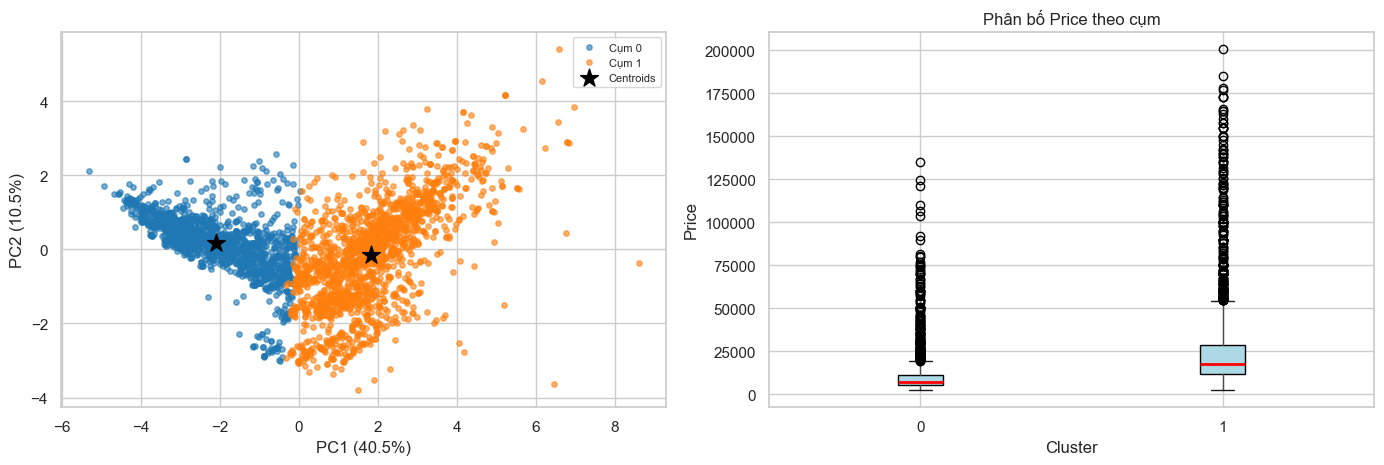

In [69]:
sns.set_theme(style="whitegrid")
COLORS = plt.cm.tab10.colors

pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X)

# Tìm k tối ưu cho K-Means bằng Elbow, Silhouette, Davies-Bouldin
K_range = range(2, 11)
km_models    = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X) for k in K_range]
km_lbls_list = [m.predict(X) for m in km_models]
inertias     = [m.inertia_ for m in km_models]
sil_scores   = [silhouette_score(X, l) for l in km_lbls_list]
db_scores    = [davies_bouldin_score(X, l) for l in km_lbls_list]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('K-Means: Tìm số cụm tối ưu', fontweight='bold')
for ax, data, title, fmt in zip(axes,
    [inertias, sil_scores, db_scores],
    ['Elbow (Inertia ↓)', 'Silhouette Score ↑', 'Davies-Bouldin ↓'],
    ['bo-', 'gs-', 'r^-']):
    ax.plot(K_range, data, fmt); ax.set_title(title); ax.set_xlabel('k')
plt.tight_layout(); plt.show()

best_idx   = np.argmax(sil_scores)
best_k     = list(K_range)[best_idx]
km_best    = km_models[best_idx]
km_labels  = km_lbls_list[best_idx]

numeric_feat   = ['RAM', 'storage', 'Battery_cap', 'num_core',
                  'primery_rear_camera', 'refresh_rate(hz)', 'display_size(inch)']
existing_feats = [f for f in numeric_feat if f in X.columns]
df_km = X.assign(Cluster=km_labels, Price=y.values)

print(f"k tối ưu = {best_k}")
print(f"Silhouette: {silhouette_score(X, km_labels):.4f} | "
      f"Davies-Bouldin: {davies_bouldin_score(X, km_labels):.4f} | "
      f"Calinski-Harabasz: {calinski_harabasz_score(X, km_labels):.2f}")
print(df_km.groupby('Cluster')[existing_feats + ['Price']].mean().round(3))
print(df_km.groupby('Cluster')['Price'].describe().round(0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'K-Means (k={best_k})', fontweight='bold')
for c in range(best_k):
    m = km_labels == c
    ax1.scatter(X_2d[m, 0], X_2d[m, 1], s=15, alpha=0.6, color=COLORS[c], label=f'Cụm {c}')
centers_2d = pca2.transform(km_best.cluster_centers_)
ax1.scatter(centers_2d[:, 0], centers_2d[:, 1], s=180, marker='*', color='black', zorder=5, label='Centroids')
ax1.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax1.legend(fontsize=8)
df_km.boxplot(column='Price', by='Cluster', ax=ax2,
              boxprops=dict(facecolor='lightblue'),
              medianprops=dict(color='red', linewidth=2), patch_artist=True)
ax2.set_title('Phân bố Price theo cụm'); ax2.set_xlabel('Cluster'); ax2.set_ylabel('Price')
plt.suptitle(''); plt.tight_layout(); plt.show()


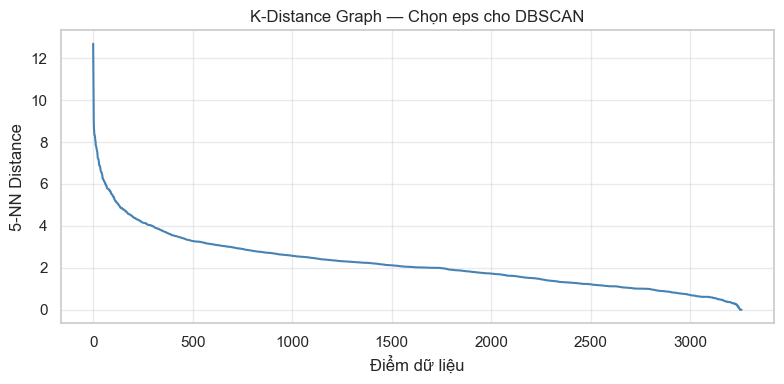

 eps  n_clusters  noise%  silhouette
 1.0          83    78.4     -0.2947
 1.5         138    57.2     -0.1383
 2.0         107    38.1     -0.1606
 2.5          33    19.7     -0.2870
 3.0          18    12.0     -0.2309
 3.5          10     7.7     -0.1711
 4.0          10     5.1     -0.1475
 4.5           8     3.2      0.0158
 5.0          10     1.9      0.0168
 5.5           8     1.0      0.1877

eps tối ưu = 5.5 | Số cụm = 8 | Noise = 31 (1.0%)
Silhouette: 0.1931 | Davies-Bouldin: 1.4096 | Calinski-Harabasz: 65.30
           RAM  storage  Battery_cap  num_core  primery_rear_camera  \
Cluster                                                               
-1       1.127    1.374        1.507     0.327                0.978   
 0      -0.025   -0.083        0.022     0.029               -0.000   
 1      -0.128    1.277       -0.815    -1.084               -0.369   
 2       2.288    3.410        0.317     0.523                0.339   
 3       1.273    0.430       -0.011     0.52

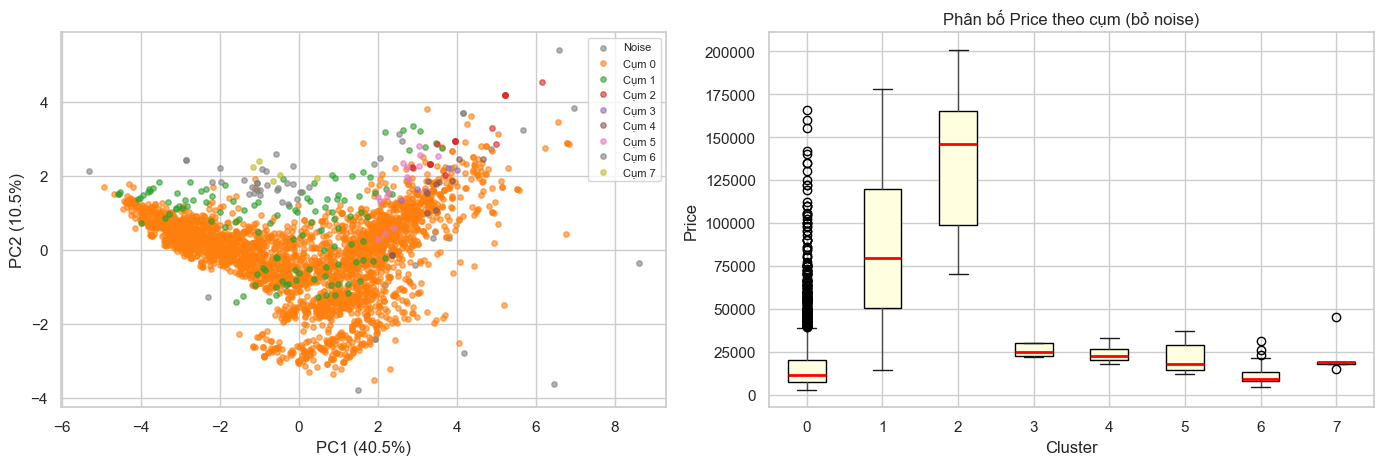

                Độ đo K-Means    DBSCAN
       Silhouette (↑)  0.2710    0.1931
   Davies-Bouldin (↓)  1.4165    1.4096
Calinski-Harabasz (↑) 1393.34     65.30
               Số cụm       2         8
                Noise  0 (0%) 31 (1.0%)


In [70]:
# K-distance graph để chọn eps cho DBSCAN
MIN_SAMPLES = 5
dist, _ = NearestNeighbors(n_neighbors=MIN_SAMPLES,  metric='manhattan').fit(X).kneighbors(X)
plt.figure(figsize=(8, 4))
plt.plot(np.sort(dist[:, -1])[::-1], color='steelblue')
plt.xlabel('Điểm dữ liệu'); plt.ylabel(f'{MIN_SAMPLES}-NN Distance')
plt.title('K-Distance Graph — Chọn eps cho DBSCAN')
plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

# Grid search eps để tìm cấu hình DBSCAN tốt nhất
best_eps, best_sil_db, best_db_labels, rows = None, -1, None, []
for eps in np.arange(1.0, 6.0, 0.5):
    lbl = DBSCAN(eps=eps, min_samples=MIN_SAMPLES,  metric='manhattan').fit_predict(X)
    n_c = len(set(lbl)) - (1 if -1 in lbl else 0)
    if n_c < 2: continue
    sil = silhouette_score(X, lbl)
    rows.append({'eps': eps, 'n_clusters': n_c,
                 'noise%': round((lbl == -1).mean() * 100, 1), 'silhouette': round(sil, 4)})
    if sil > best_sil_db:
        best_sil_db, best_eps, best_db_labels = sil, eps, lbl

print(pd.DataFrame(rows).to_string(index=False))

n_clusters_db = len(set(best_db_labels)) - (1 if -1 in best_db_labels else 0)
noise_count   = (best_db_labels == -1).sum()
mask_valid    = best_db_labels != -1
df_db = X.assign(Cluster=best_db_labels, Price=y.values)

print(f"\neps tối ưu = {best_eps} | Số cụm = {n_clusters_db} | "
      f"Noise = {noise_count} ({noise_count/len(best_db_labels)*100:.1f}%)")
print(f"Silhouette: {silhouette_score(X[mask_valid], best_db_labels[mask_valid]):.4f} | "
      f"Davies-Bouldin: {davies_bouldin_score(X[mask_valid], best_db_labels[mask_valid]):.4f} | "
      f"Calinski-Harabasz: {calinski_harabasz_score(X[mask_valid], best_db_labels[mask_valid]):.2f}")
print(df_db.groupby('Cluster')[existing_feats + ['Price']].mean().round(3))

n_labels  = sorted(set(best_db_labels))
color_map = {lbl: ('gray' if lbl == -1 else COLORS[i % 10]) for i, lbl in enumerate(n_labels)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'DBSCAN (eps={best_eps}, min_samples={MIN_SAMPLES})', fontweight='bold')
for lbl in n_labels:
    m = best_db_labels == lbl
    ax1.scatter(X_2d[m, 0], X_2d[m, 1], s=15, alpha=0.6, color=color_map[lbl],
                label='Noise' if lbl == -1 else f'Cụm {lbl}')
ax1.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax1.legend(fontsize=8)
df_db[df_db['Cluster'] != -1].boxplot(
    column='Price', by='Cluster', ax=ax2,
    boxprops=dict(facecolor='lightyellow'),
    medianprops=dict(color='red', linewidth=2), patch_artist=True)
ax2.set_title('Phân bố Price theo cụm (bỏ noise)'); ax2.set_xlabel('Cluster'); ax2.set_ylabel('Price')
plt.suptitle(''); plt.tight_layout(); plt.show()

# Bảng so sánh tổng hợp K-Means vs DBSCAN
km_s = [silhouette_score(X, km_labels),
        davies_bouldin_score(X, km_labels),
        calinski_harabasz_score(X, km_labels)]
db_s = [silhouette_score(X[mask_valid], best_db_labels[mask_valid]),
        davies_bouldin_score(X[mask_valid], best_db_labels[mask_valid]),
        calinski_harabasz_score(X[mask_valid], best_db_labels[mask_valid])]

print(pd.DataFrame({
    'Độ đo':   ['Silhouette (↑)', 'Davies-Bouldin (↓)', 'Calinski-Harabasz (↑)', 'Số cụm', 'Noise'],
    'K-Means': [f'{km_s[0]:.4f}', f'{km_s[1]:.4f}', f'{km_s[2]:.2f}', best_k, '0 (0%)'],
    'DBSCAN':  [f'{db_s[0]:.4f}', f'{db_s[1]:.4f}', f'{db_s[2]:.2f}',
                n_clusters_db, f'{noise_count} ({noise_count/len(best_db_labels)*100:.1f}%)'],
}).to_string(index=False))


1.5

NGƯỠNG PHÂN KHOẢNG GIÁ (3 lớp)
  Low   : Price ≤ 8,596
  Medium: 8,596 < Price ≤ 75,000
  High  : Price > 75,000

Số lượng mẫu mỗi lớp:
Price
Medium    2058
Low       1076
High       125
Name: count, dtype: int64


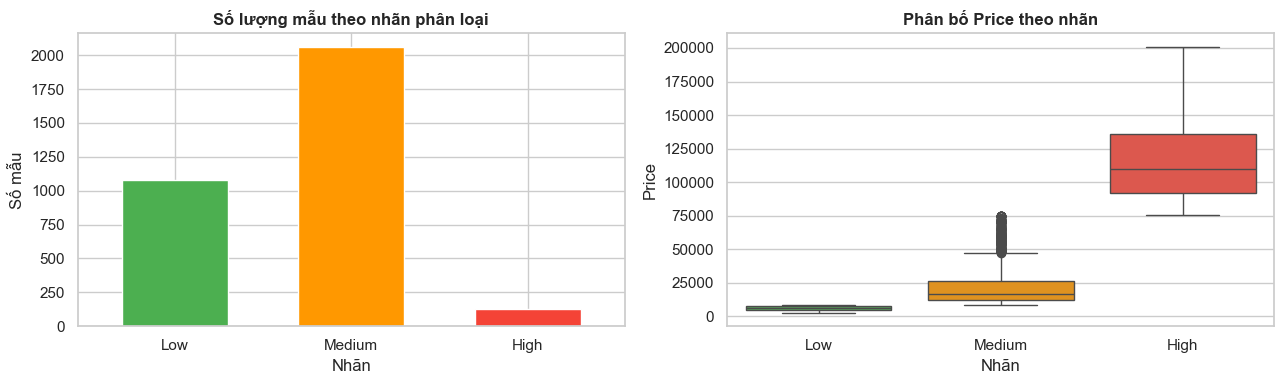


Số chiều gốc: 70  |  Số chiều PCA: 23

BẢNG KẾT QUẢ PHÂN LOẠI - GAUSSIAN NB
      Model     Data Split  Acc_Train  Acc_Test  Var_Retained
Gaussian NB      Gốc   8:2     0.6502    0.6626           NaN
Gaussian NB PCA(23d)   8:2     0.7994    0.7929       95.0813
Gaussian NB      Gốc   7:3     0.6519    0.6605           NaN
Gaussian NB PCA(23d)   7:3     0.8014    0.7904       95.1200
Gaussian NB      Gốc   6:4     0.6665    0.6787           NaN
Gaussian NB PCA(23d)   6:4     0.7980    0.7876       95.1225


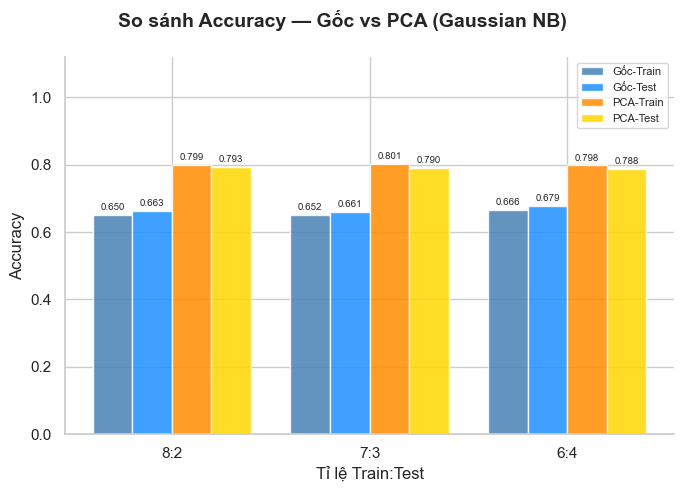


CHI TIẾT KẾT QUẢ TỈ LỆ 8:2 - GAUSSIAN NB


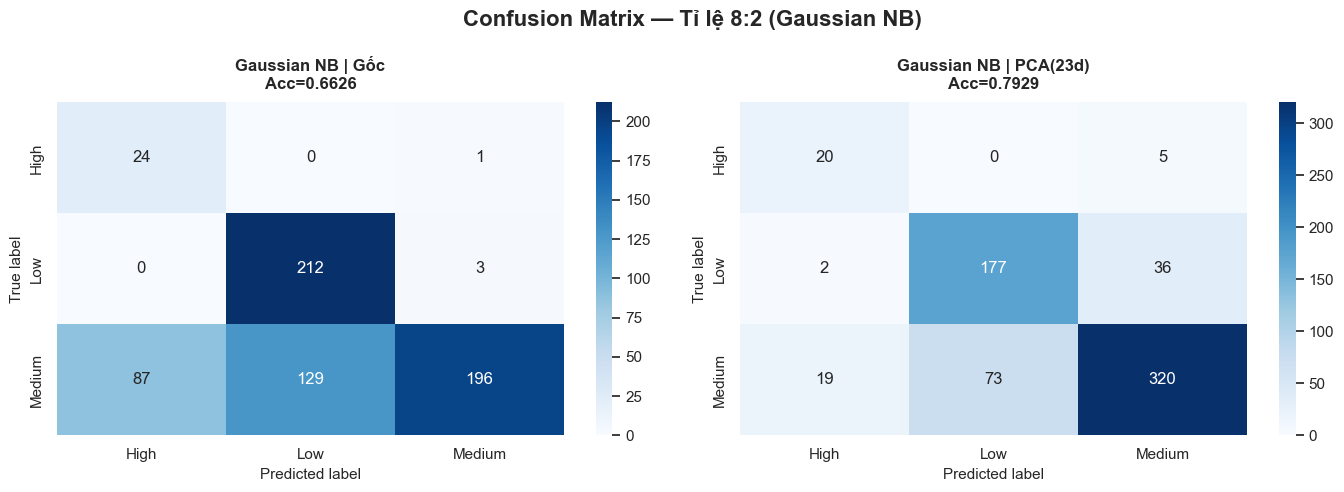


[Gaussian NB | Gốc]
              precision    recall  f1-score   support

        High     0.2162    0.9600    0.3529        25
         Low     0.6217    0.9860    0.7626       215
      Medium     0.9800    0.4757    0.6405       412

    accuracy                         0.6626       652
   macro avg     0.6060    0.8073    0.5854       652
weighted avg     0.8326    0.6626    0.6697       652


[Gaussian NB | PCA(23d)]
              precision    recall  f1-score   support

        High     0.4878    0.8000    0.6061        25
         Low     0.7080    0.8233    0.7613       215
      Medium     0.8864    0.7767    0.8279       412

    accuracy                         0.7929       652
   macro avg     0.6941    0.8000    0.7318       652
weighted avg     0.8123    0.7929    0.7975       652



In [71]:
# Phân loại giá thành 3 phân khúc: Low / Medium / High
t_low_med  = np.percentile(y, 33)
t_med_high = 75000

print("NGƯỠNG PHÂN KHOẢNG GIÁ (3 lớp)")
print(f"  Low   : Price ≤ {t_low_med:,.0f}")
print(f"  Medium: {t_low_med:,.0f} < Price ≤ {t_med_high:,.0f}")
print(f"  High  : Price > {t_med_high:,.0f}")

def price_to_label(p):
    if p <= t_low_med: return "Low"
    elif p <= t_med_high: return "Medium"
    else: return "High"

y_cat = y.apply(price_to_label)
le = LabelEncoder()
y_enc = le.fit_transform(y_cat)

print("\nSố lượng mẫu mỗi lớp:")
print(y_cat.value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
order = ['Low', 'Medium', 'High']
palette = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}

y_cat.value_counts().reindex(order).plot(
    kind='bar', ax=axes[0], color=[palette[x] for x in order],
    edgecolor='white', width=0.6)
axes[0].set_title('Số lượng mẫu theo nhãn phân loại', fontweight='bold')
axes[0].set_xlabel('Nhãn'); axes[0].set_ylabel('Số mẫu')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(x=y_cat, y=y, order=order, palette=palette, ax=axes[1])
axes[1].set_title('Phân bố Price theo nhãn', fontweight='bold')
axes[1].set_xlabel('Nhãn'); axes[1].set_ylabel('Price')
plt.tight_layout(); plt.show()

# Huấn luyện và đánh giá Gaussian NB (Gốc và PCA) trên 3 tỷ lệ chia
n_reduced = int(X.shape[1] / 3)
splits    = [0.2, 0.3, 0.4]
model_gnb = {"Gaussian NB": GaussianNB()}
results_gnb = []

print(f"\nSố chiều gốc: {X.shape[1]}  |  Số chiều PCA: {n_reduced}")

for split in splits:
    ratio = f"{int((1-split)*10)}:{int(split*10)}"
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_enc, test_size=split, random_state=42, stratify=y_enc)

    pca_s = PCA(n_components=n_reduced, random_state=42)
    X_tr_r = pca_s.fit_transform(X_tr)
    X_te_r = pca_s.transform(X_te)
    var_ret = pca_s.explained_variance_ratio_.sum() * 100

    for name, clf in model_gnb.items():
        for tag, Xtr, Xte in [("Gốc", X_tr, X_te), (f"PCA({n_reduced}d)", X_tr_r, X_te_r)]:
            clf.fit(Xtr, y_tr)
            acc_tr = accuracy_score(y_tr, clf.predict(Xtr))
            acc_te = accuracy_score(y_te, clf.predict(Xte))
            results_gnb.append({
                "Model": name, "Data": tag, "Split": ratio,
                "Acc_Train": acc_tr, "Acc_Test": acc_te,
                "Var_Retained": var_ret if tag != "Gốc" else None,
                "y_te": y_te, "y_pred": clf.predict(Xte)
            })

df_res_gnb = pd.DataFrame(results_gnb).drop(columns=["y_te","y_pred"])
print("\nBẢNG KẾT QUẢ PHÂN LOẠI - GAUSSIAN NB")
print(df_res_gnb.to_string(index=False, float_format=lambda x: f"{x:.4f}" if x else "—"))

# Biểu đồ so sánh Accuracy Gốc vs PCA
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('So sánh Accuracy — Gốc vs PCA (Gaussian NB)', fontsize=14, fontweight='bold')

x = np.arange(len(splits)); w = 0.2
labels_x = [f"{int((1-s)*10)}:{int(s*10)}" for s in splits]

goc_te = [r["Acc_Test"]  for r in results_gnb if r["Data"] == "Gốc"]
pca_te = [r["Acc_Test"]  for r in results_gnb if r["Data"] != "Gốc"]
goc_tr = [r["Acc_Train"] for r in results_gnb if r["Data"] == "Gốc"]
pca_tr = [r["Acc_Train"] for r in results_gnb if r["Data"] != "Gốc"]

b1 = ax.bar(x - 1.5*w, goc_tr, w, label='Gốc-Train', color='steelblue',   alpha=0.85)
b2 = ax.bar(x - 0.5*w, goc_te, w, label='Gốc-Test',  color='dodgerblue',  alpha=0.85)
b3 = ax.bar(x + 0.5*w, pca_tr, w, label='PCA-Train',  color='darkorange',  alpha=0.85)
b4 = ax.bar(x + 1.5*w, pca_te, w, label='PCA-Test',   color='gold',        alpha=0.85)

for bars in [b1, b2, b3, b4]:
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

ax.set_xticks(x); ax.set_xticklabels(labels_x)
ax.set_xlabel('Tỉ lệ Train:Test'); ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.12); ax.legend(fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

# Confusion Matrix và Classification Report tỷ lệ tốt nhất
best_split = max(
    [r for r in results_gnb if r["Data"] != "Gốc"],
    key=lambda r: r["Acc_Test"]
)["Split"]

print(f"\nCHI TIẾT KẾT QUẢ TỈ LỆ {best_split} - GAUSSIAN NB")

sub_03_gnb = [r for r in results_gnb if r["Split"] == best_split]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Confusion Matrix — Tỉ lệ {best_split} (Gaussian NB)', fontsize=16, fontweight='bold')

for idx, r in enumerate(sub_03_gnb):
    cm = confusion_matrix(r["y_te"], r["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[idx], cbar=True)
    axes[idx].set_title(f"{r['Model']} | {r['Data']}\nAcc={r['Acc_Test']:.4f}", fontweight='bold', pad=10)
    axes[idx].set_xlabel('Predicted label', fontsize=11)
    axes[idx].set_ylabel('True label', fontsize=11)

plt.tight_layout(); plt.show()

for r in sub_03_gnb:
    print(f"\n[{r['Model']} | {r['Data']}]")
    print(classification_report(r["y_te"], r["y_pred"], target_names=le.classes_, digits=4))


BẢNG KẾT QUẢ PHÂN LOẠI - LOGISTIC REGRESSION
       Model     Data Split  Acc_Train  Acc_Test  Var_Retained
Logistic Reg      Gốc   8:2     0.8941    0.8834           NaN
Logistic Reg PCA(23d)   8:2     0.8753    0.8804       95.0813
Logistic Reg      Gốc   7:3     0.8904    0.8855           NaN
Logistic Reg PCA(23d)   7:3     0.8777    0.8783       95.1200
Logistic Reg      Gốc   6:4     0.8982    0.8819           NaN
Logistic Reg PCA(23d)   6:4     0.8793    0.8735       95.1225


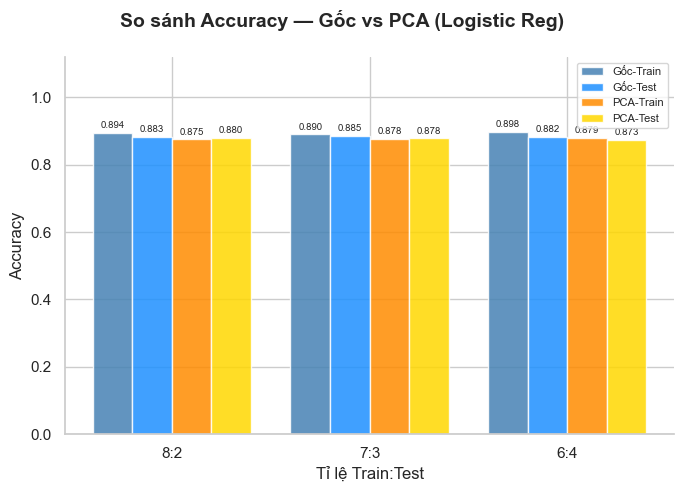


CHI TIẾT KẾT QUẢ TỈ LỆ 8:2 - LOGISTIC REGRESSION


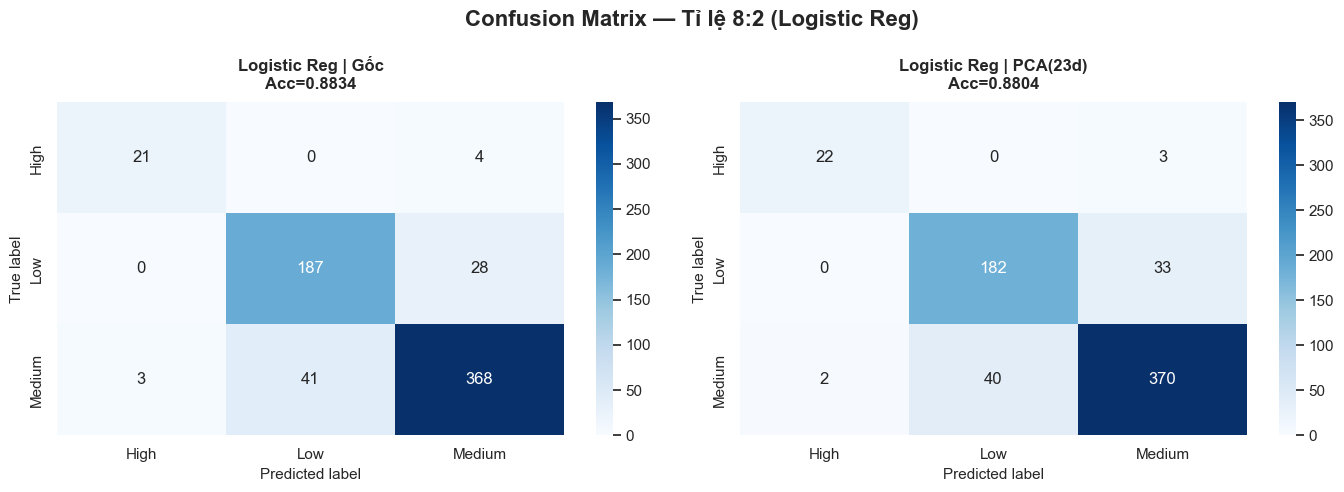


[Logistic Reg | Gốc]
              precision    recall  f1-score   support

        High     0.8750    0.8400    0.8571        25
         Low     0.8202    0.8698    0.8442       215
      Medium     0.9200    0.8932    0.9064       412

    accuracy                         0.8834       652
   macro avg     0.8717    0.8677    0.8693       652
weighted avg     0.8854    0.8834    0.8840       652


[Logistic Reg | PCA(23d)]
              precision    recall  f1-score   support

        High     0.9167    0.8800    0.8980        25
         Low     0.8198    0.8465    0.8330       215
      Medium     0.9113    0.8981    0.9046       412

    accuracy                         0.8804       652
   macro avg     0.8826    0.8749    0.8785       652
weighted avg     0.8814    0.8804    0.8807       652



In [72]:
# Huấn luyện và đánh giá Logistic Regression (Gốc và PCA) trên 3 tỷ lệ chia
model_lr = {"Logistic Reg": LogisticRegression(max_iter=1000, random_state=42)}
results_lr = []

for split in splits:
    ratio = f"{int((1-split)*10)}:{int(split*10)}"
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_enc, test_size=split, random_state=42, stratify=y_enc)

    pca_s = PCA(n_components=n_reduced, random_state=42)
    X_tr_r = pca_s.fit_transform(X_tr)
    X_te_r = pca_s.transform(X_te)
    var_ret = pca_s.explained_variance_ratio_.sum() * 100

    for name, clf in model_lr.items():
        for tag, Xtr, Xte in [("Gốc", X_tr, X_te), (f"PCA({n_reduced}d)", X_tr_r, X_te_r)]:
            clf.fit(Xtr, y_tr)
            acc_tr = accuracy_score(y_tr, clf.predict(Xtr))
            acc_te = accuracy_score(y_te, clf.predict(Xte))
            results_lr.append({
                "Model": name, "Data": tag, "Split": ratio,
                "Acc_Train": acc_tr, "Acc_Test": acc_te,
                "Var_Retained": var_ret if tag != "Gốc" else None,
                "y_te": y_te, "y_pred": clf.predict(Xte)
            })

df_res_lr = pd.DataFrame(results_lr).drop(columns=["y_te","y_pred"])
print("\nBẢNG KẾT QUẢ PHÂN LOẠI - LOGISTIC REGRESSION")
print(df_res_lr.to_string(index=False, float_format=lambda x: f"{x:.4f}" if x else "—"))

# Biểu đồ so sánh Accuracy Gốc vs PCA
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('So sánh Accuracy — Gốc vs PCA (Logistic Reg)', fontsize=14, fontweight='bold')

x = np.arange(len(splits)); w = 0.2
labels_x = [f"{int((1-s)*10)}:{int(s*10)}" for s in splits]

goc_te = [r["Acc_Test"]  for r in results_lr if r["Data"] == "Gốc"]
pca_te = [r["Acc_Test"]  for r in results_lr if r["Data"] != "Gốc"]
goc_tr = [r["Acc_Train"] for r in results_lr if r["Data"] == "Gốc"]
pca_tr = [r["Acc_Train"] for r in results_lr if r["Data"] != "Gốc"]

b1 = ax.bar(x - 1.5*w, goc_tr, w, label='Gốc-Train', color='steelblue',   alpha=0.85)
b2 = ax.bar(x - 0.5*w, goc_te, w, label='Gốc-Test',  color='dodgerblue',  alpha=0.85)
b3 = ax.bar(x + 0.5*w, pca_tr, w, label='PCA-Train',  color='darkorange',  alpha=0.85)
b4 = ax.bar(x + 1.5*w, pca_te, w, label='PCA-Test',   color='gold',        alpha=0.85)

for bars in [b1, b2, b3, b4]:
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

ax.set_xticks(x); ax.set_xticklabels(labels_x)
ax.set_xlabel('Tỉ lệ Train:Test'); ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.12); ax.legend(fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

# Confusion Matrix và Classification Report tỷ lệ tốt nhất
best_split_lr = max(
    [r for r in results_lr if r["Data"] != "Gốc"],
    key=lambda r: r["Acc_Test"]
)["Split"]

print(f"\nCHI TIẾT KẾT QUẢ TỈ LỆ {best_split_lr} - LOGISTIC REGRESSION")

sub_03_lr = [r for r in results_lr if r["Split"] == best_split_lr]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Confusion Matrix — Tỉ lệ {best_split_lr} (Logistic Reg)', fontsize=16, fontweight='bold')

for idx, r in enumerate(sub_03_lr):
    cm = confusion_matrix(r["y_te"], r["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[idx], cbar=True)
    axes[idx].set_title(f"{r['Model']} | {r['Data']}\nAcc={r['Acc_Test']:.4f}", fontweight='bold', pad=10)
    axes[idx].set_xlabel('Predicted label', fontsize=11)
    axes[idx].set_ylabel('True label', fontsize=11)

plt.tight_layout(); plt.show()

for r in sub_03_lr:
    print(f"\n[{r['Model']} | {r['Data']}]")
    print(classification_report(r["y_te"], r["y_pred"], target_names=le.classes_, digits=4))